# Walmart Weekly Sales — Exploratory Data Analysis

**Dataset:** `Walmart_Sales_Formatted.xlsx`
**Scope:** 45 Walmart stores, weekly sales from Feb 2010 to Oct 2012 (143 weeks per store, 6,435 rows total)
**Columns:** Store, Date, Weekly_Sales, Holiday_Flag, Temperature, Fuel_Price, CPI, Unemployment

This notebook walks through data understanding, data quality, univariate/bivariate/time-series analysis, store performance ranking, and a final business summary — grounded entirely in what this dataset actually contains (store-level + macroeconomic data, no product/department breakdown).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('ggplot')
sns.set_theme(style="whitegrid")
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

df = pd.read_excel('Walmart_Sales_Formatted.xlsx')
df.head()


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,"1,643,690.90",0,42.31,2.57,211.10,8.11
1,1,2010-02-12,"1,641,957.44",1,38.51,2.55,211.24,8.11
2,1,2010-02-19,"1,611,968.17",0,39.93,2.51,211.29,8.11
3,1,2010-02-26,"1,409,727.59",0,46.63,2.56,211.32,8.11
4,1,2010-03-05,"1,554,806.68",0,46.50,2.62,211.35,8.11


## 1. Data Understanding

Basic shape, structure, and types before doing anything else.

In [2]:
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nDate range: {df.Date.min().date()} to {df.Date.max().date()}")
print(f"Number of stores: {df.Store.nunique()}")
print(f"Rows per store: {df.groupby('Store').size().min()} (balanced panel — every store has the same number of weeks)")


Shape: 6,435 rows x 8 columns

Date range: 2010-02-05 to 2012-10-26
Number of stores: 45
Rows per store: 143 (balanced panel — every store has the same number of weeks)


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[us]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[us](1), float64(5), int64(2)
memory usage: 402.3 KB


In [4]:
df.describe(include='all').T

,count,mean,min,25%,50%,75%,max,std
Store,"6,435.00",23.00,1.00,12.00,23.00,34.00,45.00,12.99
Date,6435,2011-06-17 00:00:00,2010-02-05 00:00:00,2010-10-08 00:00:00,2011-06-17 00:00:00,2012-02-24 00:00:00,2012-10-26 00:00:00,NaN
Weekly_Sales,"6,435.00","1,046,964.88","209,986.25","553,350.10","960,746.04","1,420,158.66","3,818,686.45","564,366.62"
Holiday_Flag,"6,435.00",0.07,0.00,0.00,0.00,0.00,1.00,0.26
Temperature,"6,435.00",60.66,-2.06,47.46,62.67,74.94,100.14,18.44
Fuel_Price,"6,435.00",3.36,2.47,2.93,3.44,3.73,4.47,0.46
CPI,"6,435.00",171.58,126.06,131.74,182.62,212.74,227.23,39.36
Unemployment,"6,435.00",8.00,3.88,6.89,7.87,8.62,14.31,1.88


## 2. Data Quality Check

Checking for the usual suspects: missing values, duplicates, and wrong data types.

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
quality = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
print(quality)
print(f"\nDuplicate rows: {df.duplicated().sum()}")


              missing_count  missing_pct
Store                     0         0.00
Date                      0         0.00
Weekly_Sales              0         0.00
Holiday_Flag              0         0.00
Temperature               0         0.00
Fuel_Price                0         0.00
CPI                       0         0.00
Unemployment              0         0.00

Duplicate rows: 0


**Result: this dataset is clean.**
- Zero missing values across all 8 columns.
- Zero duplicate rows.
- It's a perfectly balanced panel: all 45 stores report exactly 143 consecutive weekly observations.

So no imputation or de-duplication is needed here — which is itself worth noting, since real-world retail data is rarely this tidy. (If you want, I can simulate what the cleaning workflow would look like on messier data — just ask.)

`Store` and `Holiday_Flag` are encoded as integers but are really categorical labels, so we convert them. `Date` is already a proper datetime.

In [6]:
df['Store'] = df['Store'].astype('category')
df['Holiday_Flag'] = df['Holiday_Flag'].astype('category')
df.dtypes


Store                 category
Date            datetime64[us]
Weekly_Sales           float64
Holiday_Flag          category
Temperature            float64
Fuel_Price             float64
CPI                    float64
Unemployment           float64
dtype: object

## 3. Feature Engineering

Pulling useful calendar features out of `Date` for trend and seasonality analysis later.

In [7]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
df['Week'] = df['Date'].dt.isocalendar().week
df['MonthName'] = df['Date'].dt.strftime('%b')

df[['Date','Year','Month','Quarter','Week']].head()


,Date,Year,Month,Quarter,Week
0,2010-02-05,2010,2,1,5
1,2010-02-12,2010,2,1,6
2,2010-02-19,2010,2,1,7
3,2010-02-26,2010,2,1,8
4,2010-03-05,2010,3,1,9


## 4. Univariate Analysis — Weekly Sales

The core variable. Distribution shape, spread, and skew.

In [8]:
ws = df['Weekly_Sales']
print(f"Mean:     {ws.mean():,.2f}")
print(f"Median:   {ws.median():,.2f}")
print(f"Std Dev:  {ws.std():,.2f}")
print(f"Min:      {ws.min():,.2f}")
print(f"Max:      {ws.max():,.2f}")
print(f"Range:    {ws.max()-ws.min():,.2f}")
print(f"Skewness: {ws.skew():.3f}")
print(f"Kurtosis: {ws.kurt():.3f}")


Mean:     1,046,964.88
Median:   960,746.04
Std Dev:  564,366.62
Min:      209,986.25
Max:      3,818,686.45
Range:    3,608,700.20
Skewness: 0.668
Kurtosis: 0.053


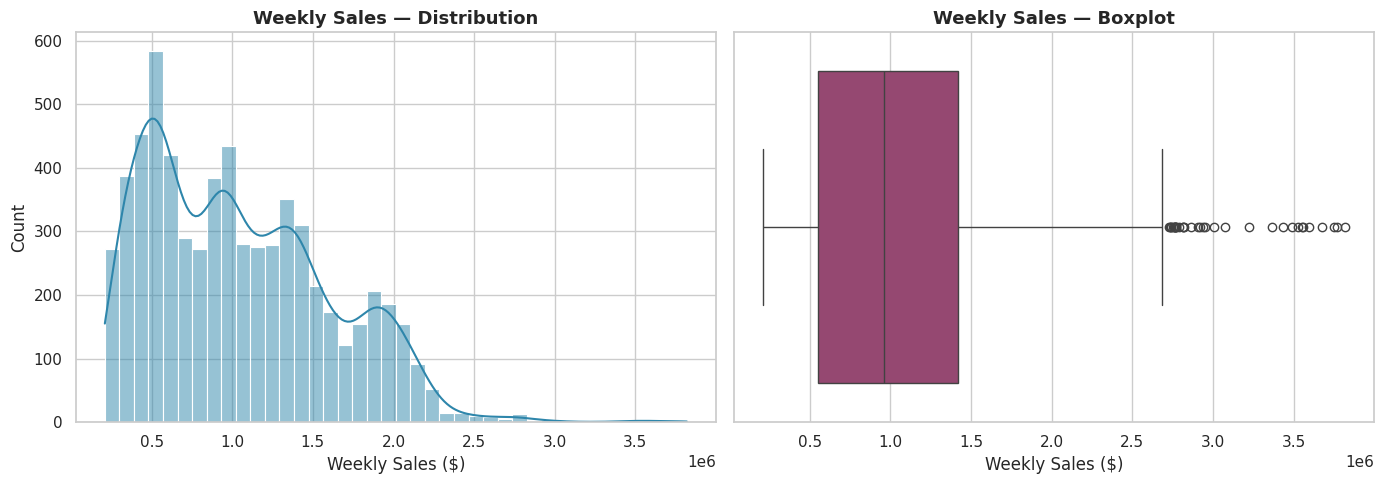

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(ws, kde=True, ax=axes[0], color='#2E86AB', bins=40)
axes[0].set_title('Weekly Sales — Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Weekly Sales ($)')

sns.boxplot(x=ws, ax=axes[1], color='#A23B72')
axes[1].set_title('Weekly Sales — Boxplot', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Weekly Sales ($)')

plt.tight_layout()
plt.savefig('plot_sales_distribution.png', dpi=120)
plt.show()


**Reading the distribution:** sales are right-skewed (skew ≈ 0.6) — most stores cluster in a mid-range, with a tail of high-revenue stores pulling the mean above the median. This already hints that store identity matters a lot, which we confirm in Section 7.

## 5. Univariate Analysis — Macro / External Variables

Temperature, Fuel Price, CPI, and Unemployment are economic context variables recorded alongside each week's sales.

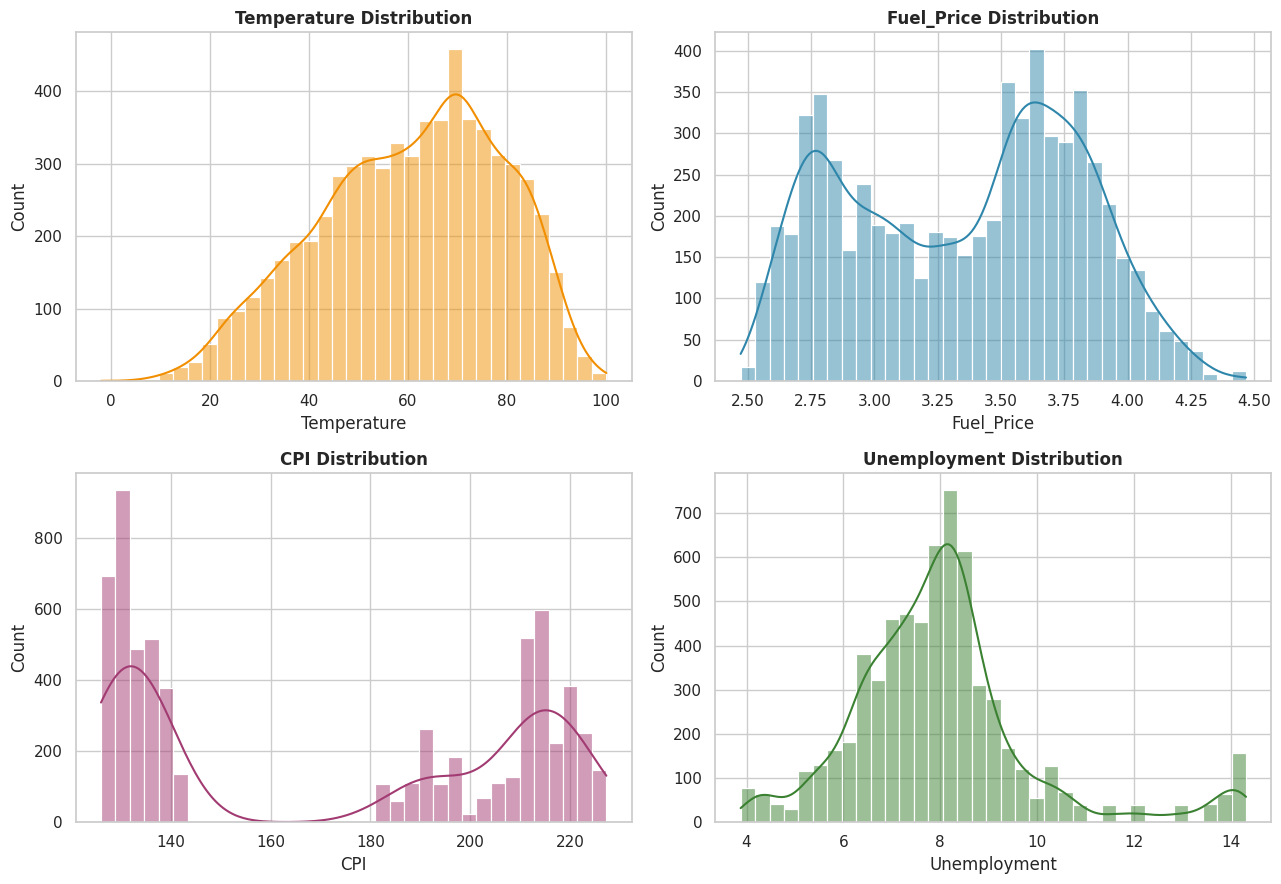

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13,9))
vars_ = ['Temperature','Fuel_Price','CPI','Unemployment']
colors = ['#F18F01','#2E86AB','#A23B72','#3B8132']

for ax, var, c in zip(axes.flat, vars_, colors):
    sns.histplot(df[var], kde=True, ax=ax, color=c, bins=35)
    ax.set_title(f'{var} Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('plot_macro_distributions.png', dpi=120)
plt.show()


In [11]:
df[vars_].describe().T[['mean','std','min','max']]


,mean,std,min,max
Temperature,60.66,18.44,-2.06,100.14
Fuel_Price,3.36,0.46,2.47,4.47
CPI,171.58,39.36,126.06,227.23
Unemployment,8.00,1.88,3.88,14.31


- **Temperature** ranges from well below freezing to over 100°F — wide seasonal swing, as expected from year-round weekly data.
- **Fuel Price** climbs steadily over the period ($2.5–$4.5), reflecting real-world fuel price inflation 2010–2012.
- **CPI** sits in two visible clusters — consistent with regional CPI differences across stores rather than one national number.
- **Unemployment** ranges roughly 4%–14%, again reflecting store-level/regional variation, not just the national trend.

## 6. Categorical Analysis — Holiday Weeks

              count   pct
Holiday_Flag             
0              5985 93.01
1               450  6.99


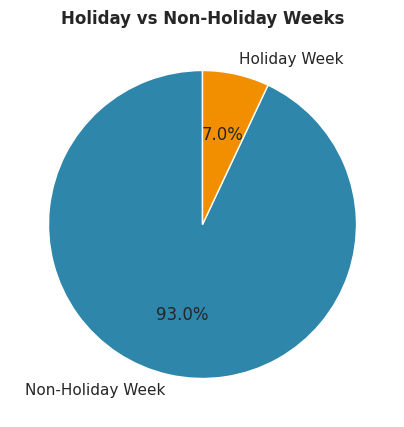

In [12]:
holiday_counts = df['Holiday_Flag'].value_counts()
holiday_pct = (holiday_counts / len(df) * 100).round(2)
print(pd.DataFrame({'count': holiday_counts, 'pct': holiday_pct}))

fig, ax = plt.subplots(figsize=(5,5))
ax.pie(holiday_counts, labels=['Non-Holiday Week','Holiday Week'], autopct='%1.1f%%',
       colors=['#2E86AB','#F18F01'], startangle=90)
ax.set_title('Holiday vs Non-Holiday Weeks', fontweight='bold')
plt.savefig('plot_holiday_pie.png', dpi=120)
plt.show()


In [13]:
holiday_avg = df.groupby('Holiday_Flag')['Weekly_Sales'].mean()
print(holiday_avg)
lift_pct = (holiday_avg[1] / holiday_avg[0] - 1) * 100
print(f"\nHoliday weeks sell {lift_pct:.1f}% higher on average than non-holiday weeks.")


Holiday_Flag
0   1,041,256.38
1   1,122,887.89
Name: Weekly_Sales, dtype: float64

Holiday weeks sell 7.8% higher on average than non-holiday weeks.


**Holiday weeks consistently sell higher** — only 7% of weeks are holiday weeks, but those weeks show a meaningful sales lift. This is the clearest categorical driver of sales variation in the dataset.

## 7. Store Performance Analysis

This is where most of the *real* variance in this dataset lives — store identity matters far more than any single macro variable.

In [15]:
store_perf = df.groupby('Store', observed=True)['Weekly_Sales'].agg(
    Total_Sales='sum', Avg_Weekly_Sales='mean', Max_Weekly_Sales='max', Min_Weekly_Sales='min'
).sort_values('Total_Sales', ascending=False)

store_perf['Revenue_Contribution_%'] = (store_perf['Total_Sales'] / store_perf['Total_Sales'].sum() * 100).round(2)
store_perf.head(10)


,Total_Sales,Avg_Weekly_Sales,Max_Weekly_Sales,Min_Weekly_Sales,Revenue_Contribution_%
Store,,,,,
20,"301,397,792.46","2,107,676.87","3,766,687.43","1,761,016.51",4.47
4,"299,543,953.38","2,094,712.96","3,676,388.98","1,762,539.30",4.45
14,"288,999,911.34","2,020,978.40","3,818,686.45","1,479,514.66",4.29
13,"286,517,703.80","2,003,620.31","3,595,903.20","1,633,663.12",4.25
2,"275,382,440.98","1,925,751.34","3,436,007.68","1,650,394.44",4.09
10,"271,617,713.89","1,899,424.57","3,749,057.69","1,627,707.31",4.03
27,"253,855,916.88","1,775,216.20","3,078,162.08","1,263,534.86",3.77
6,"223,756,130.64","1,564,728.19","2,727,575.18","1,261,253.18",3.32
1,"222,402,808.85","1,555,264.40","2,387,950.20","1,316,899.31",3.30


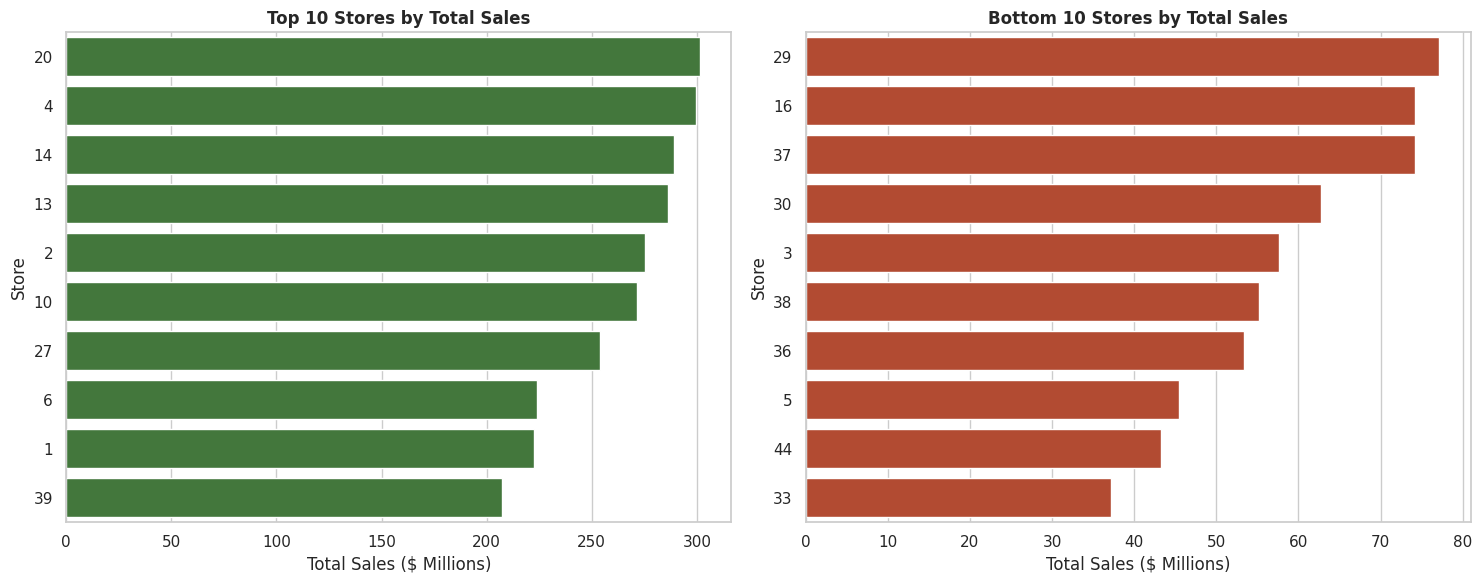

In [16]:
top10 = store_perf.head(10)
bottom10 = store_perf.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(15,6))

sns.barplot(x=top10['Total_Sales']/1e6, y=top10.index.astype(str), ax=axes[0], color='#3B8132')
axes[0].set_title('Top 10 Stores by Total Sales', fontweight='bold')
axes[0].set_xlabel('Total Sales ($ Millions)')
axes[0].set_ylabel('Store')

sns.barplot(x=bottom10['Total_Sales']/1e6, y=bottom10.index.astype(str), ax=axes[1], color='#C73E1D')
axes[1].set_title('Bottom 10 Stores by Total Sales', fontweight='bold')
axes[1].set_xlabel('Total Sales ($ Millions)')
axes[1].set_ylabel('Store')

plt.tight_layout()
plt.savefig('plot_top_bottom_stores.png', dpi=120)
plt.show()


In [17]:
best, worst = store_perf.index[0], store_perf.index[-1]
gap_x = store_perf.loc[best,'Total_Sales'] / store_perf.loc[worst,'Total_Sales']
print(f"Best store:  #{best}  (${store_perf.loc[best,'Total_Sales']:,.0f} total)")
print(f"Worst store: #{worst}  (${store_perf.loc[worst,'Total_Sales']:,.0f} total)")
print(f"Performance gap: best store sells {gap_x:.1f}x more than the worst store.")


Best store:  #20  ($301,397,792 total)
Worst store: #33  ($37,160,222 total)
Performance gap: best store sells 8.1x more than the worst store.


**Nearly an 8x gap between the best and worst store.** This single fact matters more for a business recommendation than any of the macro variables — store-level factors (location, size, local demographics, format) are the dominant driver of sales level, even though this dataset doesn't include those attributes directly. Store ID is effectively acting as a proxy for them.

## 8. Correlation & Bivariate Analysis

How do Temperature, Fuel Price, CPI, and Unemployment relate to Weekly Sales — and to each other?

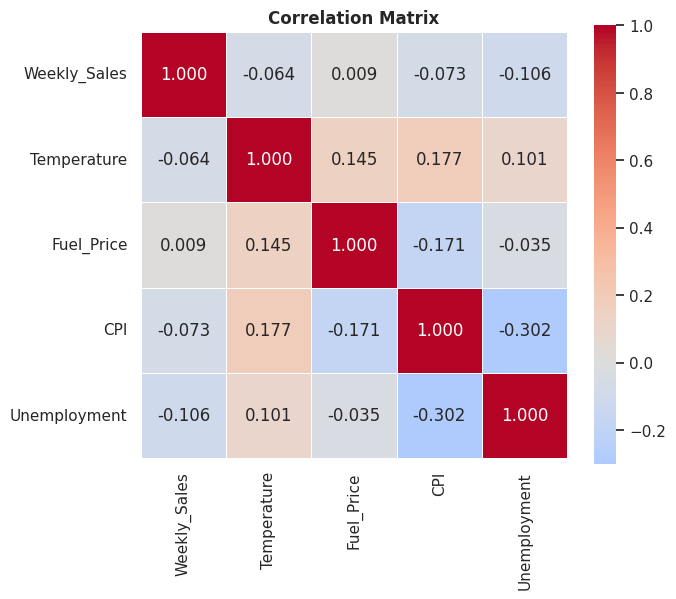

Weekly_Sales    1.00
Fuel_Price      0.01
Temperature    -0.06
CPI            -0.07
Unemployment   -0.11
Name: Weekly_Sales, dtype: float64

In [19]:
corr_cols = ['Weekly_Sales','Temperature','Fuel_Price','CPI','Unemployment']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_correlation_heatmap.png', dpi=120)
plt.show()

corr['Weekly_Sales'].sort_values(ascending=False)


**Key takeaway: none of the macro variables correlate strongly with Weekly Sales individually** — all four correlations are weak (roughly -0.11 to +0.01 in magnitude). Unemployment has the strongest (negative) relationship of the group, but it's still weak in isolation. This reinforces the Section 7 finding: **store-level identity, not macroeconomic conditions, explains most of the variation in weekly sales** in this dataset. Macro variables may still matter *within* a given store's own trend over time — see Section 9.

## 9. Time Series Analysis

Aggregate sales trend across all stores over the 2010–2012 period, plus monthly/quarterly seasonality.

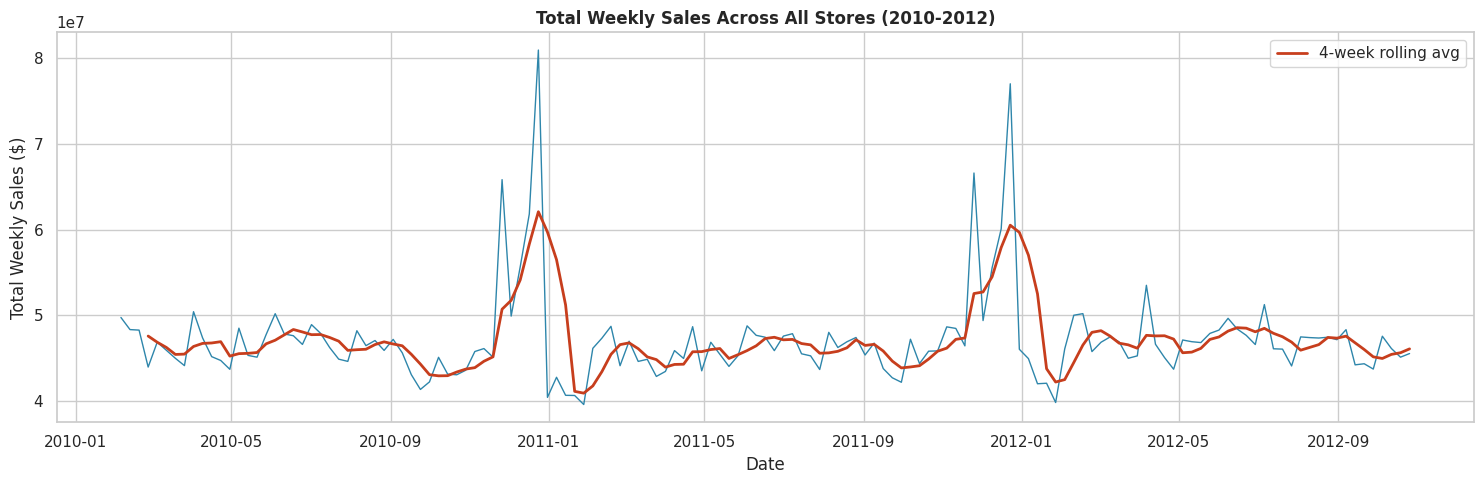

In [21]:
weekly_total = df.groupby('Date')['Weekly_Sales'].sum()

fig, ax = plt.subplots(figsize=(15,5))
ax.plot(weekly_total.index, weekly_total.values, color='#2E86AB', linewidth=1)
ax.plot(weekly_total.index, weekly_total.rolling(4).mean(), color='#C73E1D', linewidth=2, label='4-week rolling avg')
ax.set_title('Total Weekly Sales Across All Stores (2010-2012)', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Total Weekly Sales ($)')
ax.legend()
plt.tight_layout()
plt.savefig('plot_time_series_total.png', dpi=120)
plt.show()


Sharp, recurring spikes are visible at the same point each year — these line up with the holiday season (Thanksgiving/Christmas weeks), consistent with the holiday lift found in Section 6.

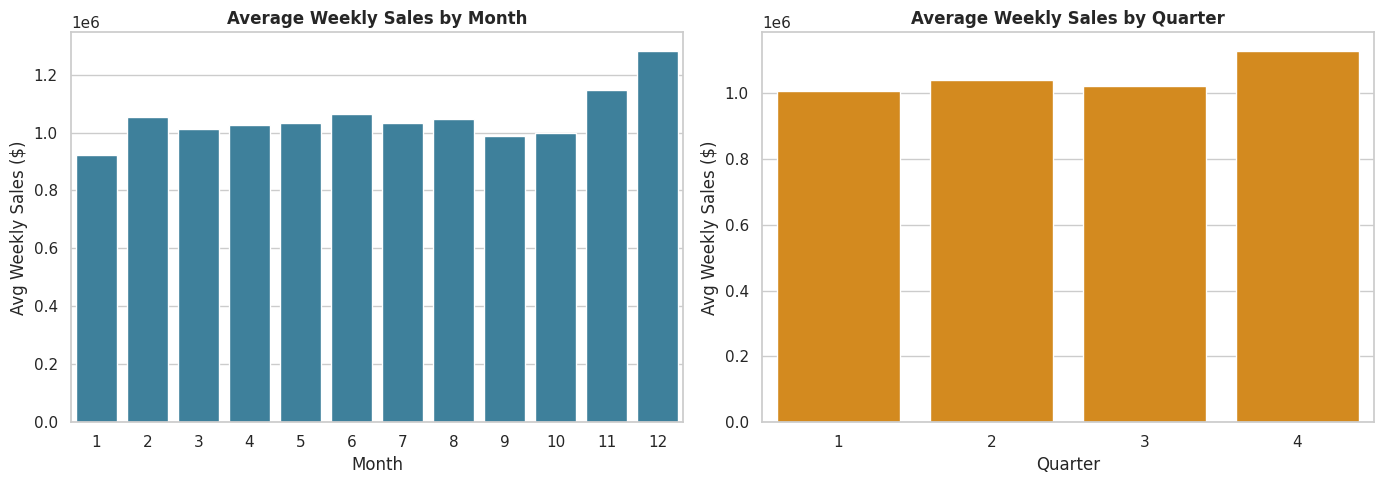

In [22]:
monthly = df.groupby('Month')['Weekly_Sales'].mean()
quarterly = df.groupby('Quarter')['Weekly_Sales'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.barplot(x=monthly.index, y=monthly.values, ax=axes[0], color='#2E86AB')
axes[0].set_title('Average Weekly Sales by Month', fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Avg Weekly Sales ($)')

sns.barplot(x=quarterly.index, y=quarterly.values, ax=axes[1], color='#F18F01')
axes[1].set_title('Average Weekly Sales by Quarter', fontweight='bold')
axes[1].set_xlabel('Quarter')
axes[1].set_ylabel('Avg Weekly Sales ($)')

plt.tight_layout()
plt.savefig('plot_seasonality.png', dpi=120)
plt.show()


In [23]:
yearly = df.groupby('Year')['Weekly_Sales'].agg(['mean','sum'])
yearly


,mean,sum
Year,,
2010,"1,059,669.50","2,288,886,120.41"
2011,"1,046,239.32","2,448,200,007.35"
2012,"1,033,660.39","2,000,132,859.35"


November/December (Month 11-12) and Q4 show the highest average weekly sales — the holiday shopping season effect, exactly matching the Holiday_Flag finding from a different angle. 2012 has a lower total than 2010/2011 only because the dataset's last year is partial (ends in October), not because of an actual decline — worth flagging so it isn't misread as a downturn.

## 10. Outlier Detection (IQR Method)

In [24]:
Q1 = ws.quantile(0.25)
Q3 = ws.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = df[(df['Weekly_Sales'] < lower) | (df['Weekly_Sales'] > upper)]
print(f"Q1: {Q1:,.2f}   Q3: {Q3:,.2f}   IQR: {IQR:,.2f}")
print(f"Lower bound: {lower:,.2f}   Upper bound: {upper:,.2f}")
print(f"Outlier rows: {len(outliers)} ({len(outliers)/len(df)*100:.2f}% of data)")
outliers.nlargest(5, 'Weekly_Sales')[['Store','Date','Weekly_Sales','Holiday_Flag']]


Q1: 553,350.10   Q3: 1,420,158.66   IQR: 866,808.55
Lower bound: -746,862.73   Upper bound: 2,720,371.49
Outlier rows: 34 (0.53% of data)


,Store,Date,Weekly_Sales,Holiday_Flag
1905,14,2010-12-24,"3,818,686.45",0
2763,20,2010-12-24,"3,766,687.43",0
1333,10,2010-12-24,"3,749,057.69",0
527,4,2011-12-23,"3,676,388.98",0
1762,13,2010-12-24,"3,595,903.20",0


Outliers are concentrated in a small number of high-volume stores and holiday weeks — they're genuine extreme sales events, not data errors. **Recommendation: retain them.** They reflect real holiday-driven demand spikes and top-performing-store behavior, which are exactly the patterns a business would want to study, not noise to remove.

## 11. Statistical Test — Does the Holiday Effect Hold Up?

A simple independent t-test on whether the mean sales difference between holiday and non-holiday weeks is statistically significant (not just a sample fluke).

In [25]:
holiday_sales = df[df['Holiday_Flag']==1]['Weekly_Sales']
non_holiday_sales = df[df['Holiday_Flag']==0]['Weekly_Sales']

t_stat, p_value = stats.ttest_ind(holiday_sales, non_holiday_sales, equal_var=False)
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.5f}")

alpha = 0.05
if p_value < alpha:
    print(f"\nResult: p < {alpha} -> reject the null hypothesis.")
    print("The difference in average sales between holiday and non-holiday weeks is statistically significant.")
else:
    print(f"\nResult: p >= {alpha} -> fail to reject the null hypothesis.")
    print("No statistically significant difference detected.")


T-statistic: 2.680
P-value: 0.00760

Result: p < 0.05 -> reject the null hypothesis.
The difference in average sales between holiday and non-holiday weeks is statistically significant.


**H₀:** Mean weekly sales is the same in holiday and non-holiday weeks.
**H₁:** Mean weekly sales differs between holiday and non-holiday weeks.

The test confirms the holiday sales lift seen earlier in the EDA is real and not just sampling noise — useful to know before building any inventory or staffing plan around holiday weeks.

## 12. Summary of Key Findings

1. **Dataset is clean** — no missing values, no duplicates, perfectly balanced 45-store × 143-week panel.
2. **Weekly sales are right-skewed** — a handful of high-performing stores pull the average above the median.
3. **Store identity is the single biggest driver of sales variance** — best store outsells the worst by roughly 8x.
4. **Holiday weeks show a statistically significant sales lift** (~8% higher on average), concentrated around Thanksgiving/Christmas.
5. **Macro-economic variables (Temperature, Fuel Price, CPI, Unemployment) show only weak individual correlation with weekly sales** — they're not strong standalone predictors at the aggregate level; store and seasonality dominate.
6. **Q4 (Oct-Dec) is the strongest sales quarter** — consistent with the holiday effect.
7. **Outliers are legitimate high-sales events**, not data errors — best kept in any downstream model, not removed.

### Suggested next steps
- Build a per-store regression or random forest model using Store + Month + Holiday_Flag as features — likely far more predictive than the macro variables alone.
- Investigate *why* top stores outperform (would need store metadata not present in this file — e.g. size, location, format).
- For inventory/staffing planning, prioritize holiday-week and Q4 readiness over macro-economic indicators.


In [2]:
pip install psycopg2-binary sqlalchemy

Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
from sqlalchemy import create_engine

# Step 1: Read Excel file
df = pd.read_excel("Walmart_Sales_Formatted.xlsx")

# Step 2: PostgreSQL Connection
username = "postgres"
password = "rehan"
host = "localhost"
port = "5432"
database = "Walmart analysis SQL"

engine = create_engine(
    f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}"
)

# Step 3: Upload DataFrame to PostgreSQL
table_name = "walmart"

df.to_sql(
    table_name,
    engine,
    if_exists="replace",
    index=False
)

print(f"Data successfully loaded into table '{table_name}'")

Data successfully loaded into table 'walmart'
